In [1]:
from PIL import Image
import torch
from transformers import AutoProcessor, Gemma3ForConditionalGeneration
from IPython.display import SVG, display, HTML

# === SETTINGS ===
model_id = "./gemma-3-4b-it"  # local path to your Gemma 3 model
image_path = "ref_image.png"
prompt_text = (
    '''
Generate SVG code to visually represent the input image exactlly, while respecting the given constraints.
<constraints>
* **Allowed Elements:** `svg`, `path`, `circle`, `rect`, `ellipse`, `line`, `polyline`, `polygon`, `g`, `linearGradient`, `radialGradient`, `stop`, `defs`
* **Allowed Attributes:** `viewBox`, `width`, `height`, `fill`, `stroke`, `stroke-width`, `d`, `cx`, `cy`, `r`, `x`, `y`, `rx`, `ry`, `x1`, `y1`, `x2`, `y2`, `points`, `transform`, `opacity`
</constraints>

Please ensure that the generated SVG code is well-formed, valid, and strictly adheres to these constraints. Focus on a clear and concise representation of the input description within the given limitations. Always give the complete SVG code with nothing omitted. Never use an ellipsis.

'''
)

# === Step 1: Load & Resize Image to 896x896 ===
image = Image.open(image_path).convert("RGB")
image = image.resize((512, 512), Image.LANCZOS)

# === Step 2: Load local model and processor ===
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16  # fallback to float16 if needed
)
processor = AutoProcessor.from_pretrained(model_id, use_fast=True)


c:\USERS\YONGSANHUANG\.CONDA\ENVS\SD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.86s/it]


In [2]:
# === Step 3: Prepare chat input ===
messages = [
    {"role": "system", "content": [{"type": "text", "text": "You are a helpful assistant."}]},
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt_text}
    ]}
]

# === Step 4: Tokenize with chat template ===
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(model.device, dtype=torch.bfloat16)

input_len = inputs["input_ids"].shape[-1]


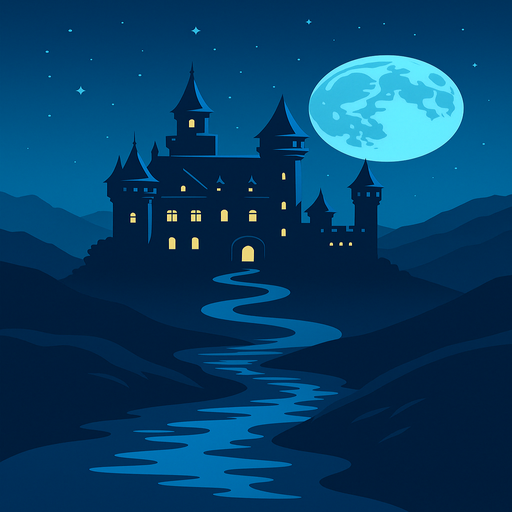

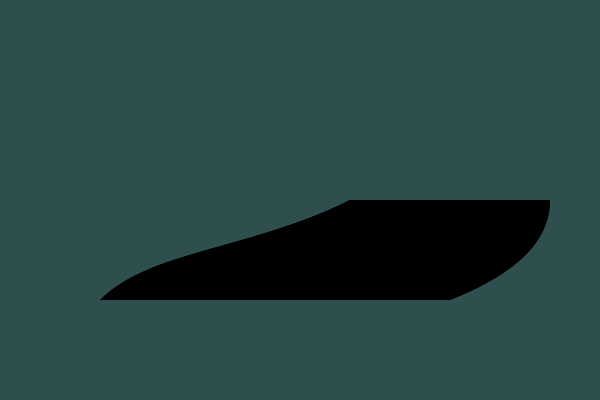

In [3]:
# === Step 5: Generate a single sampled SVG
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=1024,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        top_k=50,
        repetition_penalty=1.05,
        num_return_sequences=1
    )

# === Step 6: Decode and clean
response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)

def extract_svg(raw_text: str) -> str:
    lines = raw_text.strip().splitlines()
    return "\n".join(line for line in lines if not line.strip().startswith("```"))

svg_code = extract_svg(response)


# === Step 7: Display
display(image)
display(SVG(svg_code))

# === Optional: Save to file
with open("output.svg", "w", encoding="utf-8") as f:
    f.write(svg_code)
